# **EDA**

In [2]:
# MODULO LIBRERIAS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string, re, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab') # Download the missing resource
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from collections import Counter
from tqdm import tqdm

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 🔹Data

> Se tienen 2,484 registros de hojas de vida, resumidos en 24 categorías únicas.

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/Darally06/NLP-Jarvis-Hiring/refs/heads/main/Data/Resume.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [6]:
print("Registros:", df.shape[0])
print("Categorías únicas:", df['Category'].nunique())
cat_table = pd.DataFrame({
    'Frecuency': df['Category'].value_counts(),
    'Porcentaje': round(df['Category'].value_counts(normalize=True)*100, 2)
})
display(cat_table)

Registros: 2484
Categorías únicas: 24


,Frecuency,Porcentaje
Category,,
INFORMATION-TECHNOLOGY,120,4.83
BUSINESS-DEVELOPMENT,120,4.83
FINANCE,118,4.75
ADVOCATE,118,4.75
ACCOUNTANT,118,4.75
ENGINEERING,118,4.75
CHEF,118,4.75
AVIATION,117,4.71
FITNESS,117,4.71


>Las categorías de las hojas de vida dentro del DataSet tienen frecuencias variables, muy altas o muy bajas, que presentar un claro desbalance. Para efectos del análisis hemos de agrupar los registros en macro categorías un poco más balanceadas.

In [8]:
# Mapeo de categorías a macrogrupos

def map_macrogrupo(label):
    # Areas económico-empresariales
    if label in ['BUSINESS-DEVELOPMENT', 'ACCOUNTANT', 'FINANCE', 'BANKING', 'CONSULTANT']:
        return 'Negocios y Finanzas'
    # Innovación, técnica y sistemas
    elif label in ['INFORMATION-TECHNOLOGY', 'ENGINEERING', 'DIGITAL-MEDIA', 'AVIATION']:
        return 'Tecnología y Ciencia'
    # Profesiones orientadas a servicios
    elif label in ['ADVOCATE', 'PUBLIC-RELATIONS', 'HR', 'TEACHER', 'HEALTHCARE']:
        return 'Servicios Profesionales y Públicos'
    # Diseño, arte, moda y construcción
    elif label in ['DESIGNER', 'ARTS', 'APPAREL', 'CONSTRUCTION']:
        return 'Creatividad y Producción'
    # Áreas diversas, operativas o nicho
    elif label in ['FITNESS', 'CHEF', 'AGRICULTURE', 'AUTOMOBILE', 'BPO', 'SALES']:
        return 'Otros y Especializados'
    else:
        return 'Sin categoría'

In [9]:
df['macro_label'] = df['Category'].apply(map_macrogrupo)

print("Categorías únicas:", df['macro_label'].nunique())
cat_table = pd.DataFrame({
    'Frecuency': df['macro_label'].value_counts(),
    'Porcentaje': round(df['macro_label'].value_counts(normalize=True)*100, 2)
})
display(cat_table)

Categorías únicas: 5


,Frecuency,Porcentaje
macro_label,,
Negocios y Finanzas,586,23.59
Servicios Profesionales y Públicos,556,22.38
Otros y Especializados,472,19.00
Tecnología y Ciencia,451,18.16
Creatividad y Producción,419,16.87


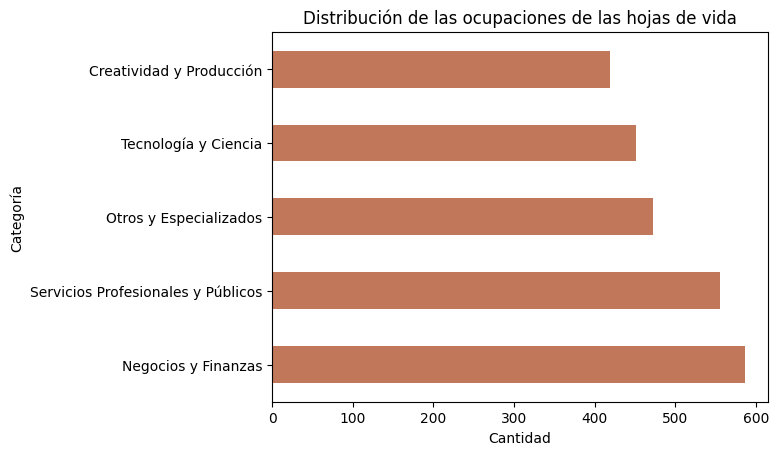

In [10]:
df['macro_label'].value_counts().plot(kind='barh', color='#C1785A')
plt.title('Distribución de las ocupaciones de las hojas de vida')
plt.xlabel('Cantidad')
plt.ylabel('Categoría')
plt.show()

Los grupos de estudio tienen una distribución bastante equilibrada, con una ligera predominancia de las hojas de vida relacionadas a las áreas de _Negocios y Finanzas_ (23.6%) y _Servicios profesionales y públicos_ (22.4%). El grupo con menor representación es el de _Creatividad y Producción_ (16.8%), pero aún así cuenta con una cantidad significativa de registros para análisis posteriores.

In [20]:
from scipy.stats import chisquare

# Conteos por categoría
observados = df['macro_label'].value_counts().sort_index()

# Esperados: proporciones iguales
esperados = [observados.sum() / len(observados)] * len(observados)

# Prueba chi-cuadrado
chi2, p = chisquare(f_obs=observados, f_exp=esperados)

print(f'Estadístico chi2: {chi2:.3f}')
print(f'Valor p: {p:.4f}')

Estadístico chi2: 40.373
Valor p: 0.0000


> De acuerdo al resultado de la prueba de Chi-Cuadrado para bondad, se rechaza la hipótesis de que las clases tengan igual proporción, es decir, las categorias no están distribuidas de manera uniforme.

## 🔹Sobre el texto

In [11]:
# Cantidad total de caracteres
df['char_len'] = df['Resume_str'].str.len()
# Cantidad de palabras en un texto separando por espacios
df['word_len'] = df['Resume_str'].apply(lambda x: len(x.split()))
# Cantidad de oraciones en el texto
df['sent_len'] = df['Resume_str'].apply(lambda x: len(sent_tokenize(x)))

# Eliminar textos vacíos
df = df[df['word_len'] > 0].reset_index(drop=True)

display(df[['char_len','word_len','sent_len']].describe())

,char_len,word_len,sent_len
count,2483.000000,2483.000000,2483.000000
mean,6297.835683,811.652437,36.343536
std,2766.943443,370.723976,23.735855
min,881.000000,113.000000,1.000000
25%,5162.500000,651.000000,21.000000
50%,5887.000000,757.000000,34.000000
75%,7227.500000,933.000000,47.000000
max,38842.000000,5190.000000,397.000000


La tabla detalla la distribución de la extensión de los textos en las hojas de vida.  En promedio, cada texto contiene aproximadamente 6,300 caracteres, 812 palabras y 36 oraciones, lo cual sugiere que se trata de documentos relativamente extensos.  

El rango es considerable: algunos textos tienen apenas 113 palabras, mientras que otros alcanzan hasta 5,190 palabras. El hecho de que el percentil 75 esté por encima de 7,200 caracteres y 933 palabras sugiere que al menos una cuarta parte de los textos son bastante densos.


## 🔹 Limpieza de texto

In [12]:
#  [Func] Limpieza de texto
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def text_cleaner(text):
    text = text.lower()
    text = re.sub(r"\n|\t", " ", text)  # elimina saltos de línea y tabulaciones
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+|\d+", " ", text)  # elimina URLs, menciones, hashtags, números
    text = re.sub(r"[_]{2,}", " ", text)  # elimina bloques como __________
    text = re.sub(r"\*", " ", text)  # elimina asteriscos
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)  # elimina puntuación restante
    text = re.sub(r"\s+", " ", text)  # colapsa múltiples espacios

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df['clean_text'] = df['Resume_str'].astype(str).apply(text_cleaner)

In [13]:
# Registros vacíos
empty_check = df[df['clean_text'].str.strip() == ""]
print(f"Registros con texto vacío: {len(empty_check)}")

df = df[df['clean_text'].str.strip() != ""]
print(f"Registros restantes: {len(df)}")


Registros con texto vacío: 0
Registros restantes: 2483


## 🔹Análisis longitudinal

In [15]:
df['word_len'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_len'] = df['clean_text'].apply(len)
display(df[['word_len', 'char_len']].describe())

,word_len,char_len
count,2483.000000,2483.000000
mean,583.997181,4793.141764
std,260.107812,2139.580719
min,74.000000,529.000000
25%,476.000000,3900.000000
50%,546.000000,4484.000000
75%,673.000000,5539.000000
max,3543.000000,27396.000000


Luego de aplicar una limpieza de texto, la distribución varia un poco. Los textos siguen teniendo rango muy amplio, con mínimo 74 palabras y 529 caracteres, llegando a un máximo de 3543 palabras y 27,396 caracteres. La media del texto contenido en la hoja de vida es de 584 palabras ($\pm$ 260) y 4,793 caracteres ($\pm$ 2139), es decir, que nos enfrentamos a textos extensos. Los casos más extremos son los textos con más de mil palabras y 75,000 caracteres.

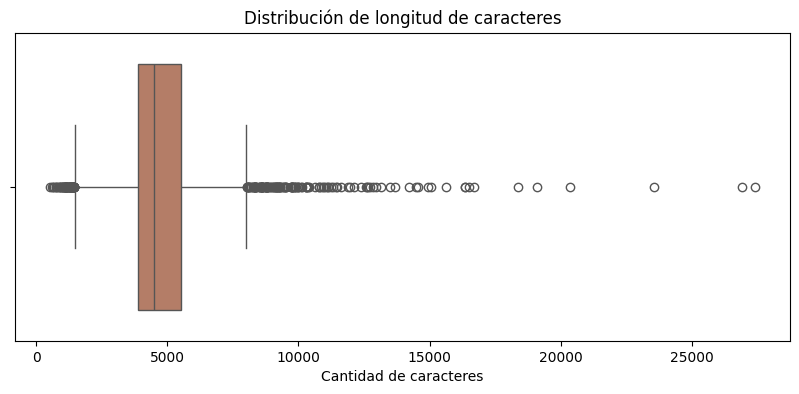

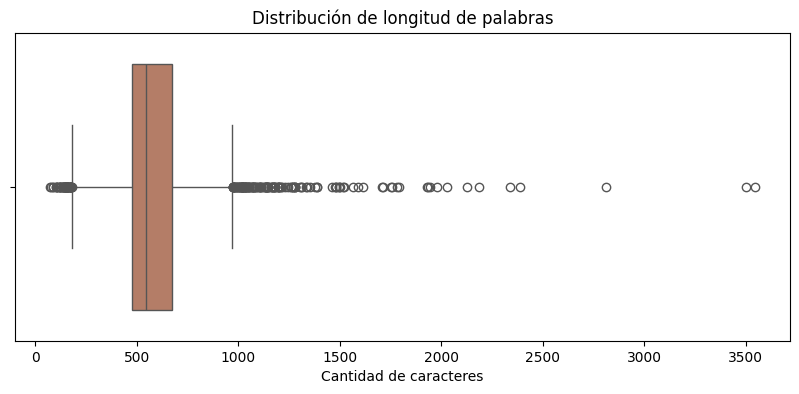

In [16]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['char_len'], color='#C1785A', orient='h')
plt.title("Distribución de longitud de caracteres")
plt.xlabel("Cantidad de caracteres")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['word_len'], color='#C1785A', orient='h')
plt.title("Distribución de longitud de palabras")
plt.xlabel("Cantidad de caracteres")
plt.show()

In [19]:
print("Cantidad de palabras promedio por categoría:")
table = df.groupby('macro_label')['word_len'].mean().reset_index()
display(table)

,macro_label,word_len
0,Creatividad y Producción,562.947494
1,Negocios y Finanzas,589.776068
2,Otros y Especializados,547.345339
3,Servicios Profesionales y Públicos,605.834532
4,Tecnología y Ciencia,607.494457


De acuerdo a las categorías, las hojas de vida del grupo _Tecnología y Ciencia_ son las que mayor cantidad de palabras presentan con 607 en promedio. Las más cortas son las relacionadas a los empleos de _Creatividad y producción_, con 562 palabras en promedio.

## 🔹Análisis de frecuencia de palabras y n-gramas

In [23]:
tokens = " ".join(df['clean_text']).split()
word_freq = Counter(tokens)
most_common = word_freq.most_common(10)

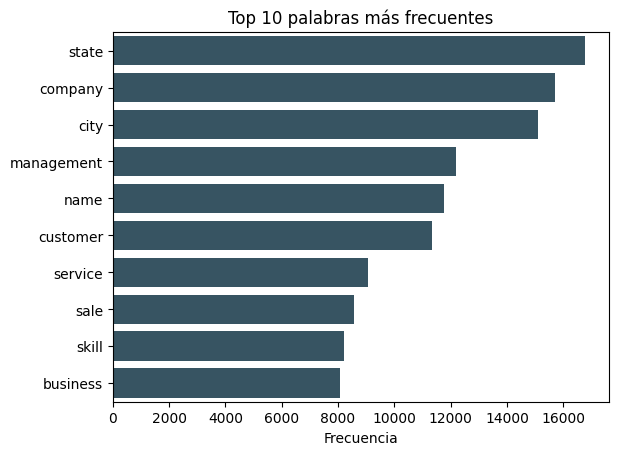

In [25]:
sns.barplot(y=[w for w,_ in most_common], x=[f for _,f in most_common], color='#305669')
plt.title('Top 10 palabras más frecuentes')
plt.xlabel('Frecuencia')
plt.show()

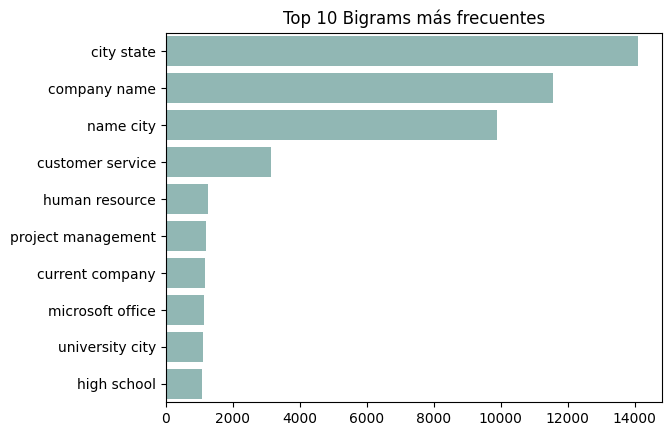

In [26]:
cv_bigram = CountVectorizer(ngram_range=(2,2), max_features=10)
bigrams = cv_bigram.fit_transform(df['clean_text'])
bigram_freq = sorted([(sum(bigrams.toarray()[:, i]), k) for k, i in cv_bigram.vocabulary_.items()], reverse=True)

sns.barplot(x=[f for f,_ in bigram_freq], y=[n for _,n in bigram_freq], color='#8ABEB9')
plt.title('Top 10 Bigrams más frecuentes')
plt.show()

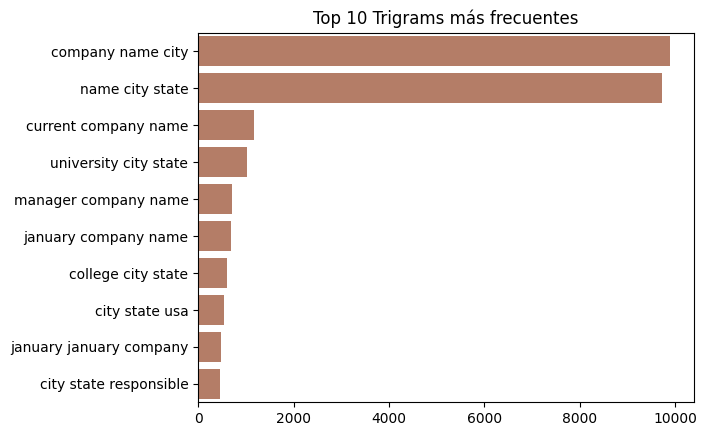

In [27]:
cv_tigram = CountVectorizer(ngram_range=(3,3), max_features=10)
trigrams = cv_tigram.fit_transform(df['clean_text'])
trigram_freq = sorted([(sum(trigrams.toarray()[:, i]), k) for k, i in cv_tigram.vocabulary_.items()], reverse=True)

sns.barplot(x=[f for f,_ in trigram_freq], y=[n for _,n in trigram_freq], color='#C1785A')
plt.title('Top 10 Trigrams más frecuentes')
plt.show()

## 🔹Nubes de palabras

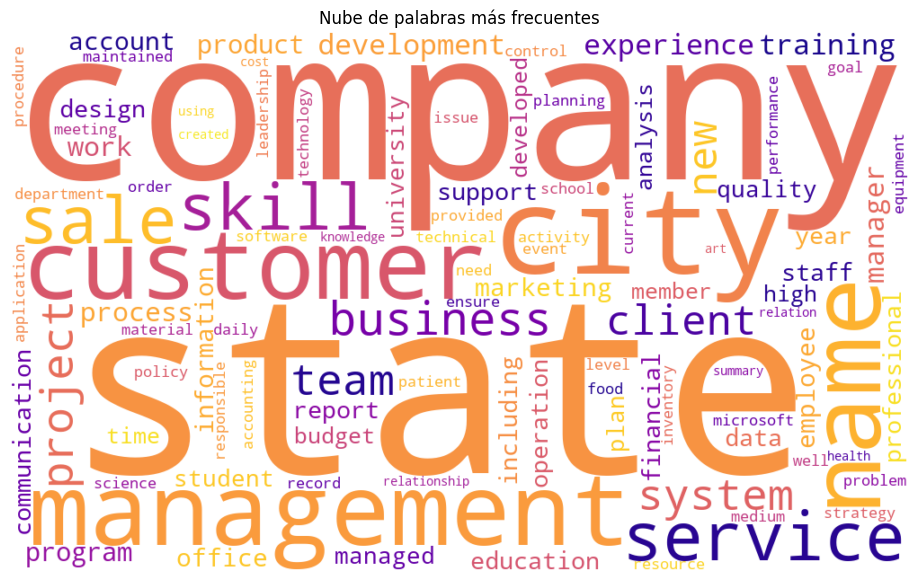

In [28]:
# Crear la nube de palabras

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='plasma',
    max_words=100
).generate_from_frequencies(word_freq)

# 3. Mostrar la nube
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras más frecuentes')
plt.show()



## 🔹Dataset preprocesado

In [34]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

final_df = df[['macro_label', 'clean_text', 'tokens']]
final_df.to_json('../Data/clean_words.json', orient='records', lines=True)

In [33]:
final_df.head()

,macro_label,clean_text,tokens
0,Servicios Profesionales y Públicos,administrator marketing associate administrato...,"[administrator, marketing, associate, administ..."
1,Servicios Profesionales y Públicos,specialist operation summary versatile medium ...,"[specialist, operation, summary, versatile, me..."
2,Servicios Profesionales y Públicos,director summary year experience recruiting pl...,"[director, summary, year, experience, recruiti..."
3,Servicios Profesionales y Públicos,specialist summary dedicated driven dynamic ye...,"[specialist, summary, dedicated, driven, dynam..."
4,Servicios Profesionales y Públicos,manager skill highlight skill department start...,"[manager, skill, highlight, skill, department,..."
